<a href="https://colab.research.google.com/github/nataliacast513/ICCU-Case-Competition/blob/main/BestInfo_ICCU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
#Importing necessary libraries
import pandas as pd
main_df = pd.read_excel("ICCUTestFile.xlsx")

#Creating ranges for Numerical Data
filter_values = [17,35,55,65,100]
out = pd.cut(main_df.Age, bins = filter_values)
main_df['Age']= out

filter_values2 = [300,580,670,740,800,850]
out2 = pd.cut(main_df.FICO, bins = filter_values2)
main_df['FICO'] = out2

filter_values3 = [0.01,0.02,0.03,0.04,0.05,0.1]
out3 = pd.cut(main_df.Rate, bins = filter_values3)
main_df['Rate'] = out3

filter_values4 = [30,50,70,90,110,130,150,170,190]
out4 = pd.cut(main_df.LoanLengthMonths, bins = filter_values4)
main_df['LoanLengthMonths'] = out4

filter_values5 = [0,1000,5000,10000,15000]
out5 = pd.cut(main_df.Amount, bins = filter_values5)
main_df['Amount'] = out5

filter_values6 = [0,100,200,300,400,500]
out6 = pd.cut(main_df.MonthlyPayment, bins = filter_values6)
main_df['MonthlyPayment'] = out6

In [3]:
#Adding labels for Age data
labels = ['18 to 35','35 to 55', '55 to 65', '65 to 100']
main_df['Age']=main_df['Age'].cat.rename_categories(labels)

In [4]:
#Functions to create sub data frames
def newCity_loan(df, city_name):
    city_df = df[df['City']==city_name]
    return city_df

def newYes_loan(df):
    df_yes = df[df['LoanApproved']=="Yes"]
    return df_yes

def newNo_loan(df):
    df_no = df[df['LoanApproved']=="No"]
    return df_no

In [5]:
#Creating sub-data frames for each city
main_yes = newYes_loan(main_df)
main_no = newNo_loan(main_df)

#Spokane dataframes
spokane_df = newCity_loan(main_df,'Spokane')
spokane_yes = newYes_loan(spokane_df)
spokane_no = newNo_loan(spokane_df)

#Boise dataframes
boise_df = newCity_loan(main_df,'Boise')
boise_yes = newYes_loan(boise_df)
boise_no = newNo_loan(boise_df)

#Meridian dataframes
meridian_df = newCity_loan(main_df,'Meridian')
meridian_yes = newYes_loan(meridian_df)
meridian_no = newNo_loan(meridian_df)

#Idaho Falls dataframes
idahofalls_df = newCity_loan(main_df,'IF')
idahofalls_yes = newYes_loan(idahofalls_df)
idahofalls_no = newNo_loan(idahofalls_df)

#Pocatello dataframes
pocatello_df = newCity_loan(main_df,'Pocatello')
pocatello_yes = newYes_loan(pocatello_df)
pocatello_no = newNo_loan(pocatello_df)

#Moscow dataframes
moscow_df = newCity_loan(main_df,'Moscow')
moscow_yes = newYes_loan(moscow_df)
moscow_no = newNo_loan(moscow_df)

In [6]:
#Functions to create graphs representing different categories

#Plot approval rates of singular column (i.e. Gender, Ethnicity, Nationality) in bar chart format
def approval_plot(df,col):
    df_plot = df.groupby([col, 'LoanApproved']).size()
    df_plot = df_plot.unstack()
    df_plot = df_plot.plot.bar(color={'Yes':'green','No':'gray'})
    df_plot.bar_label(df_plot.containers[0])
    df_plot.bar_label(df_plot.containers[1])
    return df_plot

#Plot rate ranges for specific element within column (i.e. Gender->Female, Ethnicity->Caucasian) as pie chart
def rate_plot(df,col,element):
    df2 = df[df[col]==element]
    df_plot = df2.groupby(['Rate']).size()
    df_plot = df_plot.plot(kind='pie',ylabel=' ',autopct='%1.1f%%',title=("{} Rates".format(element)))
    return df_plot

#Plot amount ranges for specific element within column (i.e. Gender->Female, Ethnicity->Caucasian) as pie chart
def amt_plot(df,col,element):
    df2 = df[df[col]==element]
    df_plot = df2.groupby(['Amount']).size()
    df_plot = df_plot.plot(kind='pie',ylabel=' ',autopct='%1.1f%%',title=("{} Amounts".format(element)))
    return df_plot

#Plot loan length ranges for specific element within column (i.e. Gender->Female, Ethnicity->Caucasian) as pie chart
def length_plot(df,col,element):
    df2 = df[df[col]==element]
    df_plot = df2.groupby(['LoanLengthMonths']).size()
    df_plot = df_plot.plot(kind='pie',ylabel=' ',autopct='%1.1f%%',title=("{} Loan Length".format(element)))
    return df_plot

#Plot monthly payment ranges for specific element within column (i.e. Gender->Female, Ethnicity->Caucasian) as pie chart
def monpay_plot(df,col,element):
    df2 = df[df[col]==element]
    df_plot = df2.groupby(['MonthlyPayment']).size()
    df_plot = df_plot.plot(kind='pie',ylabel=' ',autopct='%1.1f%%',title=("{} Monthly Payment Size".format(element)))
    return df_plot

#Plot FICO ranges for specific element within column (i.e. Gender->Female, Ethnicity->Caucasian) as pie chart
def fico_plot(df3,col,element):
    df4 = df3[df3[col]==element]
    df_plot = df4.groupby(['FICO']).size()
    df_plot = df_plot.plot(kind='pie',ylabel=' ',autopct='%1.1f%%',title=("{} FICO Scores".format(element)))
    return df_plot

#Plot composition breakdown for a singular column (i.e. Gender, Ethnicity, Nationality) as a pie chart
def percent_plot(df,col):
    return df[col].value_counts().plot(kind='pie',ylabel=' ',autopct='%1.1f%%',title=col)

<Axes: xlabel='City'>

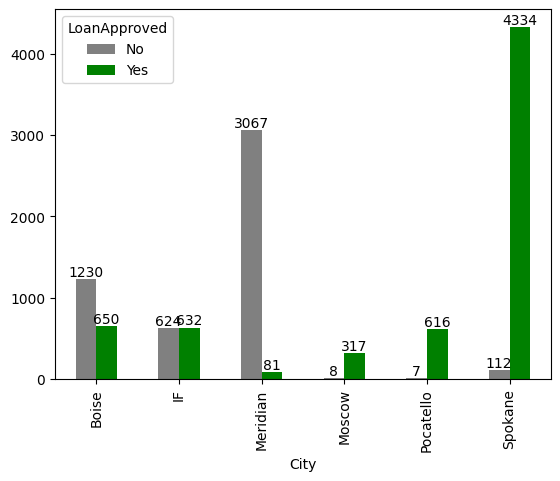

In [7]:
approval_plot(main_df,'City')

<Axes: xlabel='Gender'>

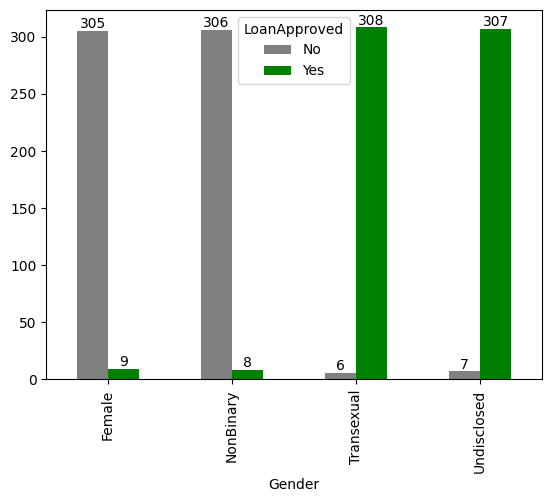

In [8]:
approval_plot(idahofalls_df,'Gender')

<Axes: title={'center': 'Gender'}, ylabel=' '>

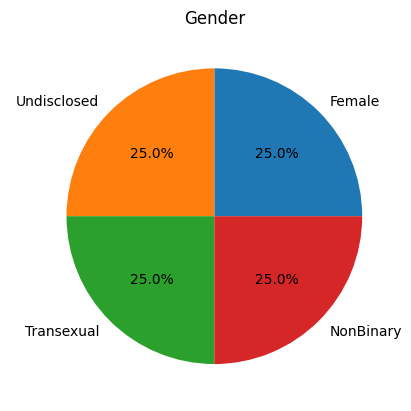

In [9]:
percent_plot(idahofalls_df,'Gender')

<Axes: title={'center': 'Gender'}, ylabel=' '>

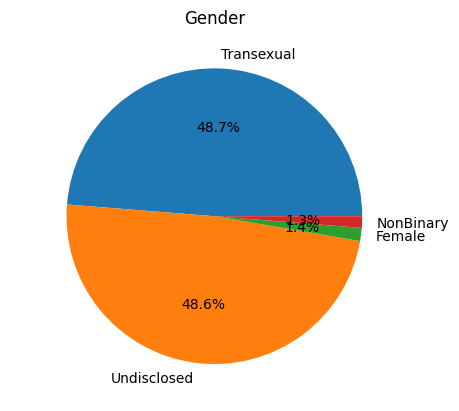

In [26]:
percent_plot(idahofalls_yes,'Gender')

/tmp/ipykernel_650/1296530222.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df4.groupby(['FICO']).size()


<Axes: title={'center': 'Female FICO Scores'}, ylabel=' '>

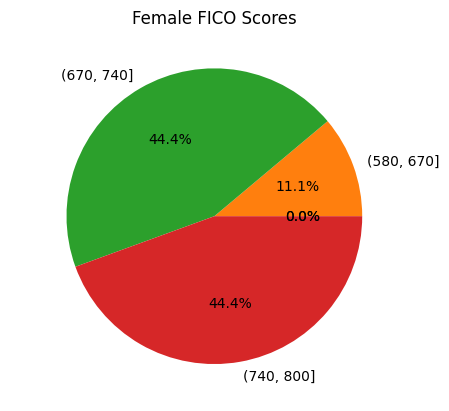

In [11]:
fico_plot(idahofalls_yes,'Gender','Female')

/tmp/ipykernel_650/1296530222.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df4.groupby(['FICO']).size()


<Axes: title={'center': 'Female FICO Scores'}, ylabel=' '>

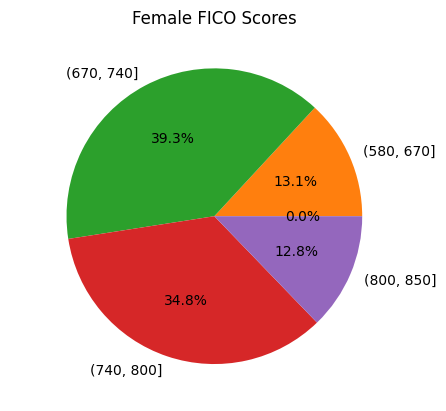

In [12]:
fico_plot(idahofalls_no,'Gender','Female')

/tmp/ipykernel_650/1296530222.py:43: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df4.groupby(['FICO']).size()


<Axes: title={'center': 'Transexual FICO Scores'}, ylabel=' '>

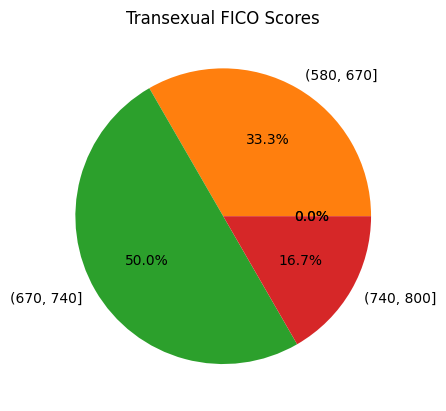

In [13]:
fico_plot(idahofalls_no,'Gender','Transexual')

/tmp/ipykernel_650/1296530222.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['Rate']).size()


<Axes: title={'center': 'Female Rates'}, ylabel=' '>

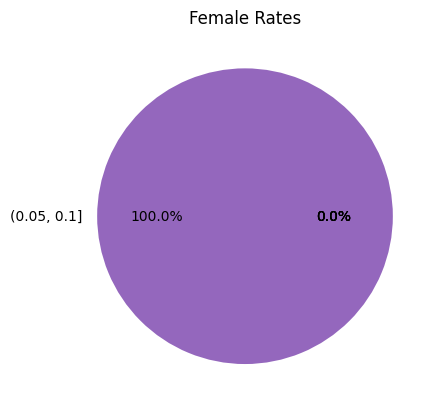

In [14]:
rate_plot(idahofalls_yes,'Gender','Female')

/tmp/ipykernel_650/1296530222.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['Rate']).size()


<Axes: title={'center': 'Female Rates'}, ylabel=' '>

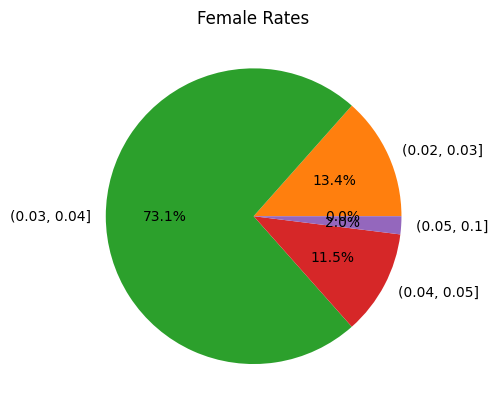

In [15]:
rate_plot(idahofalls_no,'Gender','Female')

/tmp/ipykernel_650/1296530222.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['Rate']).size()


<Axes: title={'center': 'Transexual Rates'}, ylabel=' '>

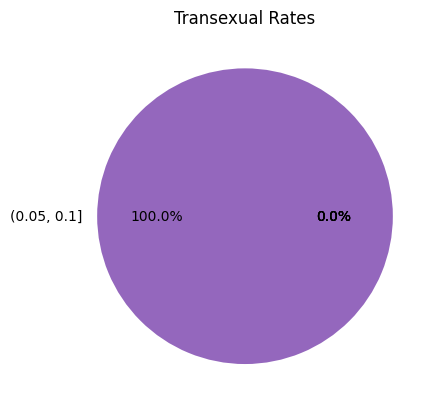

In [16]:
rate_plot(idahofalls_no,'Gender','Transexual')

/tmp/ipykernel_650/1296530222.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['Amount']).size()


<Axes: title={'center': 'Female Amounts'}, ylabel=' '>

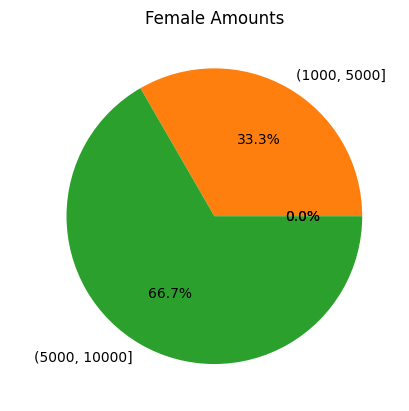

In [17]:
amt_plot(idahofalls_yes,'Gender','Female')

/tmp/ipykernel_650/1296530222.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['Amount']).size()


<Axes: title={'center': 'Female Amounts'}, ylabel=' '>

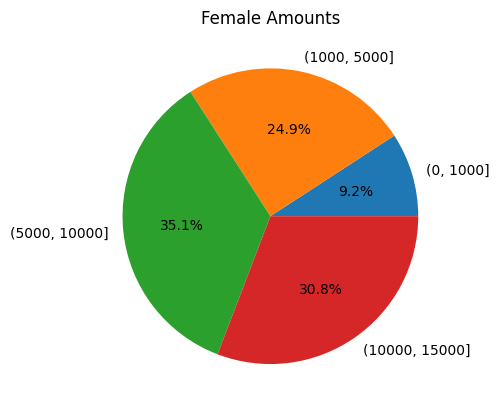

In [18]:
amt_plot(idahofalls_no,'Gender','Female')

/tmp/ipykernel_650/1296530222.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['Amount']).size()


<Axes: title={'center': 'Transexual Amounts'}, ylabel=' '>

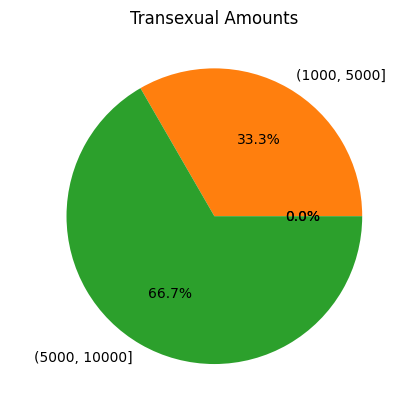

In [19]:
amt_plot(idahofalls_no,'Gender','Transexual')

/tmp/ipykernel_650/1296530222.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['LoanLengthMonths']).size()


<Axes: title={'center': 'Female Loan Length'}, ylabel=' '>

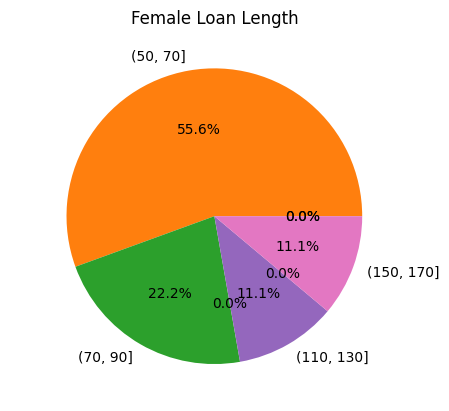

In [20]:
length_plot(idahofalls_yes,'Gender','Female')

/tmp/ipykernel_650/1296530222.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['LoanLengthMonths']).size()


<Axes: title={'center': 'Female Loan Length'}, ylabel=' '>

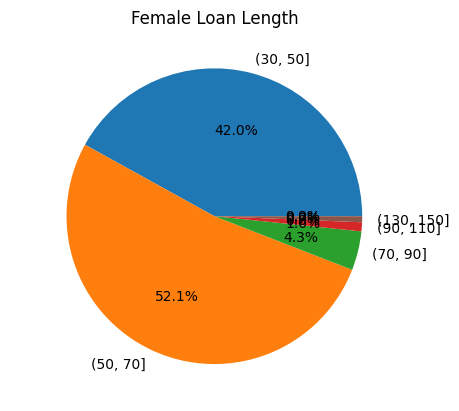

In [21]:
length_plot(idahofalls_no,'Gender','Female')

/tmp/ipykernel_650/1296530222.py:29: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['LoanLengthMonths']).size()


<Axes: title={'center': 'Transexual Loan Length'}, ylabel=' '>

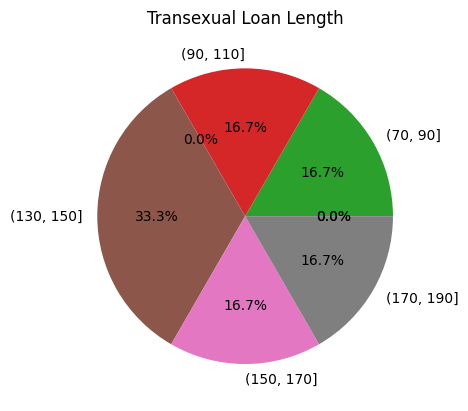

In [22]:
length_plot(idahofalls_no,'Gender','Transexual')

/tmp/ipykernel_650/1296530222.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['MonthlyPayment']).size()


<Axes: title={'center': 'Female Monthly Payment Size'}, ylabel=' '>

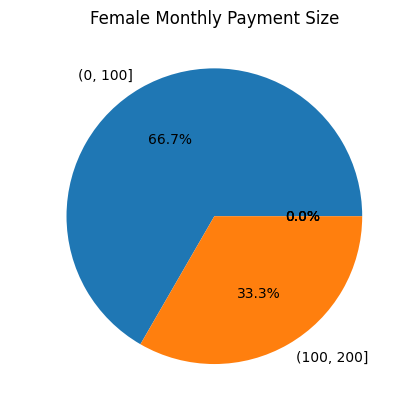

In [23]:
monpay_plot(idahofalls_yes,'Gender','Female')

/tmp/ipykernel_650/1296530222.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['MonthlyPayment']).size()


<Axes: title={'center': 'Female Monthly Payment Size'}, ylabel=' '>

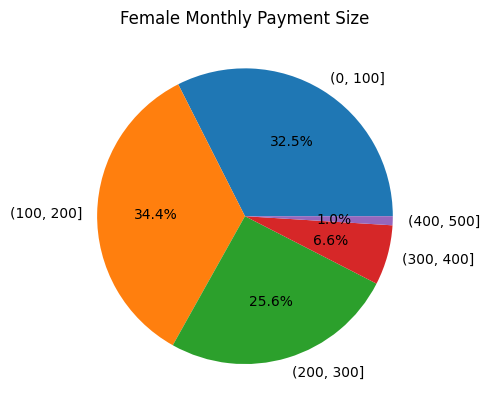

In [24]:
monpay_plot(idahofalls_no,'Gender','Female')

/tmp/ipykernel_650/1296530222.py:36: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_plot = df2.groupby(['MonthlyPayment']).size()


<Axes: title={'center': 'Transexual Monthly Payment Size'}, ylabel=' '>

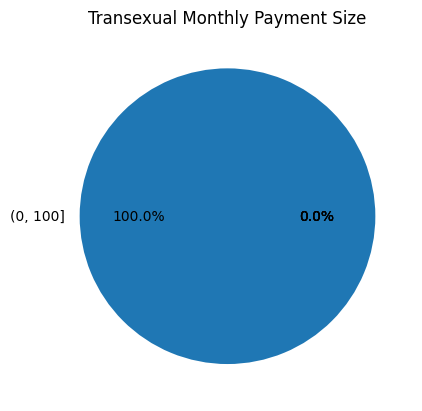

In [25]:
monpay_plot(idahofalls_no,'Gender','Transexual')